In [3]:
import pandas as pd
df = pd.read_csv("report_full_digest.csv")

In [4]:
df = df[df['tag'] != 'warm-cold']

In [4]:
df[(df['trace_name'] == 'twitter_cluster15')]

,trace_name,number_of_requests,wsr,slab_size,slab_cnt,rebalance_strategy,allocator,tag,throughput,rebalanced_slabs,miss_ratio,n_rebalanced_slabs,monitor_interval,n_alloc_failures,uuid,miss_ratio_reduction_from_disabled,miss_ratio_reduction_from_lru_disabled,tuned_improvement
260,twitter_cluster15,5263841494,0.01,1,8573,disabled,LRU,NaN,185078.055814,NaN,0.991489,0,50000,52,twitter_cluster15-81d4d360f3952693d1f70d34729e...,0.000000e+00,0.000000e+00,NaN
261,twitter_cluster15,5263841494,0.01,1,8573,marginal-hits-tuned,LRU,NaN,138586.867298,5.0,0.991489,5,50000,1,twitter_cluster15-6a6ae7193de4744316e11686fda7...,-1.899751e-10,-1.899751e-10,0.000033
262,twitter_cluster15,5263841494,0.01,1,8573,free-mem,LRU,NaN,149108.086430,1.0,0.991489,1,50000,1,twitter_cluster15-61b3578cc31564b440d4f6557657...,-1.899751e-10,-1.899751e-10,NaN
263,twitter_cluster15,5263841494,0.01,1,8573,tail-age,LRU,NaN,125134.213024,4561.0,0.991489,4561,50000,1,twitter_cluster15-b1bd4724dcf0478f28e5d73b2145...,-3.318869e-07,-3.318869e-07,NaN
264,twitter_cluster15,5263841494,0.01,1,8573,hits,LRU,NaN,150047.845067,61.0,0.991489,61,50000,1,twitter_cluster15-c29aa7cb1598ec2b7411866a0152...,2.564667e-08,2.564667e-08,NaN
265,twitter_cluster15,5263841494,0.01,1,8573,marginal-hits,LRU,NaN,131826.360494,103980.0,0.991521,103980,50000,1,twitter_cluster15-ba37f109dea8ed04b9e570b5a2fa...,-3.278366e-05,-3.278366e-05,NaN
266,twitter_cluster15,5263841494,0.01,1,8573,free-mem,LRU2Q,NaN,160249.494392,1.0,0.991489,1,50000,1,twitter_cluster15-6a2aa599f1572d41db532a7cb7f4...,-1.329827e-09,3.799508e-10,NaN
267,twitter_cluster15,5263841494,0.01,1,8573,tail-age,LRU2Q,NaN,162248.875439,3.0,0.991489,3,50000,1,twitter_cluster15-6470bf196d828b051219c8a8ba13...,2.849630e-09,4.559408e-09,NaN
269,twitter_cluster15,5263841494,0.01,1,8573,marginal-hits,LRU2Q,cold,194603.438279,55824.0,0.991519,55824,50000,1,twitter_cluster15-755687ace0a7326a10b8a92c03d6...,-3.076232e-05,-3.076061e-05,NaN
271,twitter_cluster15,5263841494,0.01,1,8573,disabled,LRU2Q,NaN,119629.227770,NaN,0.991489,0,50000,52,twitter_cluster15-ee33af45a2b5915a2f0bc4d335d9...,0.000000e+00,1.709778e-09,NaN


In [3]:
# Filter data for WSR = 0.01
wsr_001_data = df[df['wsr'] == 0.01]

# Group by allocator and rebalance_strategy, then find min and max miss_ratio_reduction_from_disabled
grouped_stats = wsr_001_data.groupby(['allocator', 'rebalance_strategy'])['miss_ratio_reduction_from_disabled'].agg(['min', 'max', 'count']).reset_index()

# Rename columns for clarity
grouped_stats.columns = ['allocator', 'rebalance_strategy', 'smallest_miss_ratio_reduction', 'largest_miss_ratio_reduction', 'count']

# Sort by allocator and then by largest value for better readability
grouped_stats = grouped_stats.sort_values(['allocator', 'largest_miss_ratio_reduction'], ascending=[True, False])

print("Largest and smallest miss_ratio_reduction_from_disabled by allocator and rebalance_strategy (WSR = 0.01):")
display(grouped_stats)

Largest and smallest miss_ratio_reduction_from_disabled by allocator and rebalance_strategy (WSR = 0.01):


,allocator,rebalance_strategy,smallest_miss_ratio_reduction,largest_miss_ratio_reduction,count
3,LRU,marginal-hits,-0.030974,0.327597,37
2,LRU,hits,-0.111038,0.324264,37
4,LRU,marginal-hits-tuned,-0.011133,0.297546,37
5,LRU,tail-age,-0.012734,0.072676,37
1,LRU,free-mem,-0.009897,0.000191,37
0,LRU,disabled,0.000000,0.000000,37
8,LRU2Q,hits,-0.111944,0.326902,37
9,LRU2Q,marginal-hits,-0.032587,0.322723,37
10,LRU2Q,marginal-hits-tuned,-0.015153,0.322610,37
11,LRU2Q,tail-age,-0.027750,0.155721,37


In [8]:
# Filter data for WSR = 0.1
wsr_01_data = df[df['wsr'] == 0.1]

# Initialize list to store results
results = []

# Group by allocator and rebalance_strategy
for allocator in wsr_01_data['allocator'].unique():
    allocator_data = wsr_01_data[wsr_01_data['allocator'] == allocator]
    
    # Find row with minimum miss_ratio_reduction_from_disabled
    min_row = allocator_data.loc[allocator_data['miss_ratio_reduction_from_disabled'].idxmin()]
    
    # Find row with maximum miss_ratio_reduction_from_disabled
    max_row = allocator_data.loc[allocator_data['miss_ratio_reduction_from_disabled'].idxmax()]
    
    # Add min result
    results.append({
        'allocator': allocator,
        'type': 'smallest',
        'rebalance_strategy': min_row['rebalance_strategy'],
        'miss_ratio_reduction': min_row['miss_ratio_reduction_from_disabled'],
        'trace_name': min_row['trace_name']
    })
    
    # Add max result
    results.append({
        'allocator': allocator,
        'type': 'largest',
        'rebalance_strategy': max_row['rebalance_strategy'],
        'miss_ratio_reduction': max_row['miss_ratio_reduction_from_disabled'],
        'trace_name': max_row['trace_name']
    })

# Convert to DataFrame
result_df = pd.DataFrame(results)

# Sort by allocator and type
result_df = result_df.sort_values(['allocator', 'type'])

print("Largest and smallest miss_ratio_reduction_from_disabled by allocator with rebalance_strategy (WSR = 0.1):")
display(result_df)

Largest and smallest miss_ratio_reduction_from_disabled by allocator with rebalance_strategy (WSR = 0.1):


,allocator,type,rebalance_strategy,miss_ratio_reduction,trace_name
1,LRU,largest,marginal-hits-tuned,0.240071,twitter_cluster34
0,LRU,smallest,marginal-hits,-0.020238,twitter_cluster29
3,LRU2Q,largest,marginal-hits-tuned,0.194130,twitter_cluster34
2,LRU2Q,smallest,marginal-hits,-0.026039,twitter_cluster29
5,TINYLFU,largest,marginal-hits-tuned,0.213570,twitter_cluster34
4,TINYLFU,smallest,marginal-hits,-0.024863,twitter_cluster35


In [7]:
def analyze_positive_negative_ratios(df, wsr=None):
    """
    Analyze the ratio of positive and negative miss_ratio_reduction_from_disabled
    for each rebalance strategy and allocator combination.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the experiment results
    wsr (float, optional): Working Set Ratio to filter by. If None, use all data.
    
    Returns:
    pd.DataFrame: DataFrame with positive/negative ratios for each strategy-allocator combination
    """
    # Filter by WSR if specified
    if wsr is not None:
        df = df[df['wsr'] == wsr]
    
    # Initialize results list
    results = []

    # Get unique rebalance strategies (excluding disabled since it's the baseline)
    strategies = df[df['rebalance_strategy'] != 'disabled']['rebalance_strategy'].unique()

    # For each rebalance strategy
    for strategy in strategies:
        # Filter data for this strategy
        strategy_data = df[df['rebalance_strategy'] == strategy]
        
        # Group by allocator
        for allocator in strategy_data['allocator'].unique():
            allocator_data = strategy_data[strategy_data['allocator'] == allocator]
            
            # Count positive and negative values
            positive_count = len(allocator_data[allocator_data['miss_ratio_reduction_from_disabled'] > 0])
            negative_count = len(allocator_data[allocator_data['miss_ratio_reduction_from_disabled'] < 0])
            zero_count = len(allocator_data[allocator_data['miss_ratio_reduction_from_disabled'] == 0])
            total_count = len(allocator_data)
            
            # Calculate ratios
            positive_ratio = positive_count / total_count if total_count > 0 else 0
            negative_ratio = negative_count / total_count if total_count > 0 else 0
            zero_ratio = zero_count / total_count if total_count > 0 else 0
            
            results.append({
                'rebalance_strategy': strategy,
                'allocator': allocator,
                'positive_count': positive_count,
                'negative_count': negative_count,
                'zero_count': zero_count,
                'total_count': total_count,
                'positive_ratio': positive_ratio,
                'negative_ratio': negative_ratio,
                'zero_ratio': zero_ratio
            })

    # Convert to DataFrame
    ratio_df = pd.DataFrame(results)

    # Sort by rebalance_strategy and allocator for better readability
    ratio_df = ratio_df.sort_values(['rebalance_strategy', 'allocator'])

    return ratio_df

In [8]:
ratio_results = analyze_positive_negative_ratios(df, 0.01)
print("Ratio of positive/negative miss_ratio_reduction_from_disabled by rebalance strategy and allocator:")
display(ratio_results)

Ratio of positive/negative miss_ratio_reduction_from_disabled by rebalance strategy and allocator:


,rebalance_strategy,allocator,positive_count,negative_count,zero_count,total_count,positive_ratio,negative_ratio,zero_ratio
12,free-mem,LRU,8,14,15,37,0.216216,0.378378,0.405405
13,free-mem,LRU2Q,8,14,15,37,0.216216,0.378378,0.405405
14,free-mem,TINYLFU,9,13,15,37,0.243243,0.351351,0.405405
9,hits,LRU,29,6,2,37,0.783784,0.162162,0.054054
10,hits,LRU2Q,29,6,2,37,0.783784,0.162162,0.054054
11,hits,TINYLFU,27,8,2,37,0.729730,0.216216,0.054054
0,marginal-hits,LRU,18,19,0,37,0.486486,0.513514,0.000000
1,marginal-hits,LRU2Q,16,20,1,37,0.432432,0.540541,0.027027
2,marginal-hits,TINYLFU,17,19,1,37,0.459459,0.513514,0.027027
3,marginal-hits-tuned,LRU,28,7,2,37,0.756757,0.189189,0.054054


In [10]:
"""
df, group by rebalance_strategy and wsr, in each group find the row with the min 3 miss_ratio_reduction_from_lru_disabled 
show columns: rebalance_strategy, allocator, wsr, miss_ratio_reduction_from_lru_disabled,
"""

# Group by rebalance_strategy and wsr
grouped = df[(df['rebalance_strategy'].isin(['hits', 'tail-age', 'marginal-hits', 'marginal-hits-tuned'])) & 
             (df['allocator'] == 'LRU')].groupby(['rebalance_strategy', 'wsr'])

# Find the rows with the minimum 3 values of miss_ratio_reduction_from_lru_disabled in each group
result = grouped.apply(lambda group: group.nsmallest(5, 'miss_ratio_reduction_from_disabled'))

# Reset the index and select the required columns
result = result.reset_index(drop=True)\
    [['rebalance_strategy', 'allocator', 'trace_name', 'wsr', \
        'miss_ratio_reduction_from_lru_disabled', 'miss_ratio_reduction_from_disabled']]

# Display the result
display(result)

/tmp/ipykernel_48969/857255467.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = grouped.apply(lambda group: group.nsmallest(5, 'miss_ratio_reduction_from_disabled'))


,rebalance_strategy,allocator,trace_name,wsr,miss_ratio_reduction_from_lru_disabled,miss_ratio_reduction_from_disabled
0,hits,LRU,twitter_cluster49,0.01,-0.111038,-0.111038
1,hits,LRU,twitter_cluster54,0.01,-0.012390,-0.012390
2,hits,LRU,twitter_cluster28,0.01,-0.002471,-0.002471
3,hits,LRU,twitter_cluster45,0.01,-0.002347,-0.002347
4,hits,LRU,twitter_cluster20,0.01,-0.000701,-0.000701
5,hits,LRU,twitter_cluster27,0.10,-0.009572,-0.009572
6,hits,LRU,twitter_cluster44,0.10,-0.003909,-0.003909
7,hits,LRU,twitter_cluster9,0.10,-0.001342,-0.001342
8,hits,LRU,twitter_cluster17,0.10,-0.000625,-0.000625
9,hits,LRU,twitter_cluster18,0.10,-0.000238,-0.000238


In [2]:
"""
group by trace_name, wsr and allocator 
in each group, find the row whose rebalance_strategy is marginal-hits-tuned
another row is hits 
compute the miss ratio difference of the tune, sort in descending order
"""
# Group by trace_name, wsr, and allocator
grouped = df.groupby(['trace_name', 'wsr', 'allocator'])

# Initialize a list to store results
results = []

# Iterate through each group
for name, group in grouped:
    # Find rows for marginal-hits-tuned and hits
    tuned_row = group[group['rebalance_strategy'] == 'marginal-hits-tuned']
    hits_row = group[group['rebalance_strategy'] == 'hits']
    
    # Ensure both rows exist
    if not tuned_row.empty and not hits_row.empty:
        # Compute the miss ratio difference
        tuned_miss_ratio = tuned_row.iloc[0]['miss_ratio']
        hits_miss_ratio = hits_row.iloc[0]['miss_ratio']
        miss_ratio_diff = tuned_miss_ratio - hits_miss_ratio
        
        # Append the result
        results.append({
            'trace_name': name[0],
            'wsr': name[1],
            'allocator': name[2],
            'miss_ratio_diff': miss_ratio_diff
        })

# Convert results to a DataFrame
result_df = pd.DataFrame(results)

# Sort by miss ratio difference in descending order
result_df = result_df.sort_values(by='miss_ratio_diff', ascending=False)

# Group by trace_name, wsr, and allocator
grouped = df.groupby(['trace_name', 'wsr', 'allocator'])

# Initialize a list to store results
results = []

# Iterate through each group
for name, group in grouped:
    # Find rows for marginal-hits-tuned and hits
    tuned_row = group[group['rebalance_strategy'] == 'marginal-hits-tuned']
    hits_row = group[group['rebalance_strategy'] == 'hits']
    
    # Ensure both rows exist
    if not tuned_row.empty and not hits_row.empty:
        # Compute the miss ratio difference
        tuned_miss_ratio = tuned_row.iloc[0]['miss_ratio']
        hits_miss_ratio = hits_row.iloc[0]['miss_ratio']
        miss_ratio_diff = tuned_miss_ratio - hits_miss_ratio
        
        # Append the result
        results.append({
            'trace_name': name[0],
            'wsr': name[1],
            'allocator': name[2],
            'miss_ratio_diff': miss_ratio_diff
        })

# Convert results to a DataFrame
result_df = pd.DataFrame(results)

# Sort by miss ratio difference in descending order
result_df = result_df.sort_values(by='miss_ratio_diff', ascending=False)

# Display the result
result_df[result_df['allocator'] == 'LRU']

,trace_name,wsr,allocator,miss_ratio_diff
167,twitter_cluster41,0.01,LRU,0.040017
161,twitter_cluster40,0.01,LRU,0.032703
219,twitter_cluster50,0.01,LRU,0.026719
33,twitter_cluster14,0.01,LRU,0.022225
131,twitter_cluster36,0.01,LRU,0.017055
...,...,...,...,...
252,twitter_cluster8,0.10,LRU,-0.019987
89,twitter_cluster27,0.10,LRU,-0.024330
234,twitter_cluster53,0.01,LRU,-0.047548
122,twitter_cluster34,0.10,LRU,-0.063393


In [48]:
df[(df['rebalance_strategy'] == 'tail-age') & (
    df['miss_ratio_reduction_from_disabled'] < 0
) & (df['allocator'] == 'LRU')].sort_values(by='miss_ratio_reduction_from_disabled')[['trace_name', 'wsr', 'allocator', 'miss_ratio_reduction_from_disabled', 'miss_ratio', 'n_rebalanced_slabs', 'uuid']]

,trace_name,wsr,allocator,miss_ratio_reduction_from_disabled,miss_ratio,n_rebalanced_slabs,uuid
124,twitter_cluster11,0.01,LRU,-1.273410e-02,0.466493,4,twitter_cluster11-3a7898eae2e7daf93140efc50a7e...
1610,twitter_cluster54,0.01,LRU,-9.898602e-03,0.555482,5,twitter_cluster54-81b621828a11511327c0bbc92408...
1262,twitter_cluster45,0.01,LRU,-2.735109e-03,0.449115,17,twitter_cluster45-9d65d7c75afec844158fb89e59c3...
1574,twitter_cluster53,0.01,LRU,-1.809769e-03,0.313274,1,twitter_cluster53-90dd11dd7ce61107ebb62185bd19...
1435,twitter_cluster5,0.01,LRU,-1.773147e-03,0.231742,65,twitter_cluster5-4f3d30ca03b2822ae53eccff99cddb34
580,twitter_cluster27,0.01,LRU,-1.704442e-03,0.631911,275,twitter_cluster27-098d41eab078566465b8519fd1e4...
45,meta_202401,0.01,LRU,-1.581831e-03,0.155271,978,meta_202401_kv_traces_all_sort-584fd267a09bfec...
622,twitter_cluster28,0.01,LRU,-6.750338e-04,0.039012,52,twitter_cluster28-b3802184b603c4a9d6868800e481...
386,twitter_cluster20,0.01,LRU,-4.564498e-04,0.070979,95,twitter_cluster20-3fb2d6fb5f6371e8acdd373ad4f6...
25,meta_202210,0.10,LRU,-4.424915e-04,0.053554,7360,meta_202210_kv_traces_all_sort-b9948ea896309ae...


In [2]:
df.columns

Index(['trace_name', 'number_of_requests', 'wsr', 'slab_size', 'slab_cnt',
       'rebalance_strategy', 'allocator', 'tag', 'throughput',
       'rebalanced_slabs', 'miss_ratio', 'n_rebalanced_slabs',
       'monitor_interval', 'n_alloc_failures', 'uuid',
       'miss_ratio_reduction_from_disabled',
       'miss_ratio_reduction_from_lru_disabled', 'tuned_improvement'],
      dtype='object')

In [3]:
df['trace_name'].unique()

array(['meta_202210', 'meta_202401', 'twitter_cluster10',
       'twitter_cluster11', 'twitter_cluster12', 'twitter_cluster13',
       'twitter_cluster14', 'twitter_cluster15', 'twitter_cluster16',
       'twitter_cluster17', 'twitter_cluster18', 'twitter_cluster19',
       'twitter_cluster20', 'twitter_cluster21', 'twitter_cluster22',
       'twitter_cluster23', 'twitter_cluster24', 'twitter_cluster26',
       'twitter_cluster27', 'twitter_cluster28', 'twitter_cluster29',
       'twitter_cluster3', 'twitter_cluster30', 'twitter_cluster31',
       'twitter_cluster32', 'twitter_cluster33', 'twitter_cluster34',
       'twitter_cluster35', 'twitter_cluster36', 'twitter_cluster37',
       'twitter_cluster38', 'twitter_cluster39', 'twitter_cluster4',
       'twitter_cluster40', 'twitter_cluster41', 'twitter_cluster42',
       'twitter_cluster43', 'twitter_cluster44', 'twitter_cluster45',
       'twitter_cluster46', 'twitter_cluster47', 'twitter_cluster48',
       'twitter_cluster49', 'twitt

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
def plot_modern_boxplot(
    df,
    wsr,
    special_whisker=False,
    show_legend=True,
    ax=None
):
    allocator_map = {
        "LRU": "LRU",
        "LRU2Q": "TwoQ",
        "TINYLFU": "TinyLFU"
    }
    rebalance_map = {
        "disabled": r"$\it{Disabled}$",
        "free-mem": r"$\it{Free\text{-}Memory}$",
        "tail-age": r"$\it{Lru\text{-}Tail\text{-}Age}$",
        "hits": r"$\it{Hits\text{-}Per\text{-}Slab}$",
        "marginal-hits": r"$\it{Marginal\text{-}Hits}$",
        "marginal-hits-tuned": r"$\it{Marginal\text{-}Hits\text{-}Tuned}$"
    }
    vivid_palette = {
        r"$\it{Disabled}$": "#636EFA",
        r"$\it{Free\text{-}Memory}$": "#EF553B",
        r"$\it{Lru\text{-}Tail\text{-}Age}$": "#00CC96",
        r"$\it{Hits\text{-}Per\text{-}Slab}$": "#AB63FA",
        r"$\it{Marginal\text{-}Hits}$": "#FFA15A",
        r"$\it{Marginal\text{-}Hits\text{-}Tuned}$": "#19D3F3"
    }
    triangle_color = "#FF007F"

    # Filter and map data
    plot_df = df.copy()
    plot_df = plot_df[plot_df['wsr'] == wsr]
    if "allocator" in plot_df.columns:
        plot_df["allocator"] = plot_df["allocator"].map(allocator_map)
    if "rebalance_strategy" in plot_df.columns:
        plot_df["rebalance_strategy"] = plot_df["rebalance_strategy"].map(rebalance_map)
        # Only include strategies present in the data
        present_strategies = plot_df["rebalance_strategy"].unique()
        plot_df["rebalance_strategy"] = pd.Categorical(
            plot_df["rebalance_strategy"],
            categories=[rebalance_map[key] for key in rebalance_map if rebalance_map[key] in present_strategies],
            ordered=True
        )

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "mathtext.fontset": "custom"
    })

    if ax is None:
        ax = plt.gca()
    box = sns.boxplot(
        x="allocator",
        y="miss_ratio_reduction_from_lru_disabled",
        data=plot_df,
        palette=[vivid_palette[key] for key in plot_df["rebalance_strategy"].cat.categories if key in vivid_palette],
        hue="rebalance_strategy",
        showfliers=False,
        linewidth=2,
        boxprops=dict(alpha=1),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        whis=(10, 90) if special_whisker else 1.5,
        ax=ax
    )

    # Add mean markers
    groups = plot_df.groupby(["allocator", "rebalance_strategy"])
    for name, group in groups:
        x_val, hue_val = name
        alloc_levels = list(plot_df["allocator"].unique())
        hue_levels = plot_df["rebalance_strategy"].cat.categories
        x_pos = alloc_levels.index(x_val)
        hue_pos = hue_levels.tolist().index(hue_val)
        n_hue = len(hue_levels)
        pos = x_pos - 0.4 + 0.8 * (hue_pos + 0.5) / n_hue
        mean_val = group["miss_ratio_reduction_from_lru_disabled"].mean()
        ax.scatter(
            pos, mean_val, marker='v', color=triangle_color, edgecolors='red', s=40, zorder=3
        )

    # Add vertical dashed lines to separate eviction policies
    alloc_levels = list(plot_df["allocator"].unique())
    for i in range(1, len(alloc_levels)):
        ax.axvline(x=i - 0.5, color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("Eviction Policy", fontsize=15)
    ax.set_ylabel("Miss Ratio Reduction from\nLRU + Disabled", fontsize=15)
    ax.grid(axis='y', linestyle='-', alpha=0.18)
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    if show_legend:
        ax.legend(title="Rebalance Strategy", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=13, title_fontsize=14, frameon=False)
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

In [57]:
def plot_modern_boxplot_log_scale(
    df,
    wsr,
    special_whisker=False,
    show_legend=True,
    ax=None
):
    allocator_map = {
        "LRU": "LRU",
        "LRU2Q": "TwoQ",
        "TINYLFU": "TinyLFU"
    }
    rebalance_map = {
        "disabled": r"$\it{Disabled}$",
        "tail-age": r"$\it{Lru\text{-}Tail\text{-}Age}$",
        "hits": r"$\it{Hits\text{-}Per\text{-}Slab}$",
        "marginal-hits": r"$\it{Marginal\text{-}Hits}$",
        "marginal-hits-tuned": r"$\it{Marginal\text{-}Hits\text{-}Tuned}$"
    }
    vivid_palette = {
        r"$\it{Disabled}$": "#636EFA",
        r"$\it{Lru\text{-}Tail\text{-}Age}$": "#00CC96",
        r"$\it{Hits\text{-}Per\text{-}Slab}$": "#AB63FA",
        r"$\it{Marginal\text{-}Hits}$": "#FFA15A",
        r"$\it{Marginal\text{-}Hits\text{-}Tuned}$": "#19D3F3"
    }
    triangle_color = "#FF007F"

    # Filter and map data
    plot_df = df.copy()
    plot_df = plot_df[plot_df['wsr'] == wsr]
    if "allocator" in plot_df.columns:
        plot_df["allocator"] = plot_df["allocator"].map(allocator_map)
    if "rebalance_strategy" in plot_df.columns:
        plot_df["rebalance_strategy"] = plot_df["rebalance_strategy"].map(rebalance_map)
        # Only include strategies present in the data
        present_strategies = plot_df["rebalance_strategy"].unique()
        plot_df["rebalance_strategy"] = pd.Categorical(
            plot_df["rebalance_strategy"],
            categories=[rebalance_map[key] for key in rebalance_map if rebalance_map[key] in present_strategies],
            ordered=True
        )

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "mathtext.fontset": "custom"
    })

    if ax is None:
        ax = plt.gca()
    box = sns.boxplot(
        x="allocator",
        y="n_rebalanced_slabs",
        data=plot_df,
        palette=[vivid_palette[key] for key in plot_df["rebalance_strategy"].cat.categories if key in vivid_palette],
        hue="rebalance_strategy",
        showfliers=False,
        linewidth=2,
        boxprops=dict(alpha=1),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        whis=(10, 90) if special_whisker else 1.5,
        ax=ax
    )

    # Add mean markers
    groups = plot_df.groupby(["allocator", "rebalance_strategy"])
    for name, group in groups:
        x_val, hue_val = name
        alloc_levels = list(plot_df["allocator"].unique())
        hue_levels = plot_df["rebalance_strategy"].cat.categories
        x_pos = alloc_levels.index(x_val)
        hue_pos = hue_levels.tolist().index(hue_val)
        n_hue = len(hue_levels)
        pos = x_pos - 0.4 + 0.8 * (hue_pos + 0.5) / n_hue
        mean_val = group["n_rebalanced_slabs"].mean()
        ax.scatter(
            pos, mean_val, marker='v', color=triangle_color, edgecolors='red', s=40, zorder=3
        )

    # Add vertical dashed lines to separate eviction policies
    alloc_levels = list(plot_df["allocator"].unique())
    for i in range(1, len(alloc_levels)):
        ax.axvline(x=i - 0.5, color="gray", linestyle="--", linewidth=1)

    ax.set_yscale("log")  # Apply log scale to the y-axis
    ax.set_xlabel("Eviction Policy", fontsize=15)
    ax.set_ylabel("Number of Rebalanced Slabs\n(Log Scale)", fontsize=15)
    ax.grid(axis='y', linestyle='-', alpha=0.18)
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    if show_legend:
        ax.legend(title="Rebalance Strategy", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=13, title_fontsize=14, frameon=False)
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

In [20]:
def summarize_column(df, col_name, group_by_cols=None):
    if group_by_cols:
        grouped = df.groupby(group_by_cols)
        summary = grouped[col_name].agg(
            mean='mean',
            std='std',
            min='min',
            max='max',
            p10=lambda x: np.percentile(x, 10),
            p25=lambda x: np.percentile(x, 25),
            p50=lambda x: np.percentile(x, 50),
            p75=lambda x: np.percentile(x, 75),
            p90=lambda x: np.percentile(x, 90)
        ).reset_index()
    else:
        summary = pd.DataFrame({
            'mean': [df[col_name].mean()],
            'std': [df[col_name].std()],
            'min': [df[col_name].min()],
            'max': [df[col_name].max()],
            'p10': [np.percentile(df[col_name], 10)],
            'p25': [np.percentile(df[col_name], 25)],
            'p50': [np.percentile(df[col_name], 50)],
            'p75': [np.percentile(df[col_name], 75)],
            'p90': [np.percentile(df[col_name], 90)]
        })
    return summary

In [36]:
summarize_column(df[df['wsr'] == 0.01], 'miss_ratio_reduction_from_lru_disabled', group_by_cols=['allocator', 'rebalance_strategy'])

,allocator,rebalance_strategy,mean,std,min,max,p10,p25,p50,p75,p90
0,LRU,disabled,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
1,LRU,free-mem,-0.000717,0.002233,-0.009897,0.000191,-9.596498e-04,-1.955391e-04,0.000000e+00,0.000000,1.042782e-07
2,LRU,hits,0.024964,0.062865,-0.111038,0.324264,-1.359431e-03,2.256947e-09,1.125240e-03,0.036963,7.345380e-02
3,LRU,marginal-hits,0.026051,0.062557,-0.030974,0.327597,-9.660066e-03,-5.576339e-04,-2.236842e-09,0.034999,7.687109e-02
4,LRU,marginal-hits-tuned,0.025721,0.055204,-0.011133,0.297546,-6.694756e-04,7.449212e-10,2.104402e-03,0.037555,6.260589e-02
5,LRU,tail-age,0.010695,0.023691,-0.012734,0.072676,-1.787796e-03,-2.131033e-04,2.443396e-07,0.004510,5.532533e-02
6,LRU2Q,disabled,0.009517,0.010996,-0.004503,0.036674,0.000000e+00,3.373984e-07,6.255799e-03,0.016370,2.526134e-02
7,LRU2Q,free-mem,0.008867,0.009976,-0.004503,0.035784,5.989331e-10,1.112962e-06,6.255799e-03,0.013706,2.165344e-02
8,LRU2Q,hits,0.031593,0.065006,-0.116447,0.329394,4.469527e-10,6.752025e-06,1.235963e-02,0.047873,8.961062e-02
9,LRU2Q,marginal-hits,0.025015,0.064552,-0.131112,0.336944,-6.511171e-03,-4.428444e-04,9.909884e-04,0.029197,8.036358e-02


/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1604480178.py:71: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1604480178.py:71: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



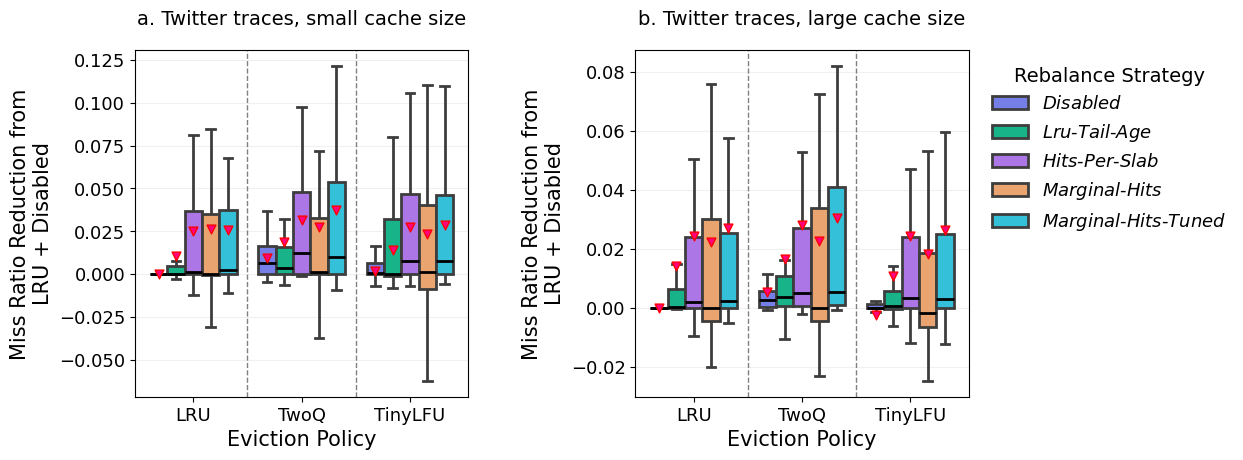

In [60]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.5}  # Increase wspace
)

# Plot the boxplots
plot_modern_boxplot(df[df['rebalance_strategy'] != 'free-mem'], 0.01, special_whisker=False, show_legend=False, ax=axes[0])
plot_modern_boxplot(df[df['rebalance_strategy'] != 'free-mem'], 0.1, special_whisker=False, show_legend=True, ax=axes[1])

# Add labels to the subplots
axes[0].set_title("a. Twitter traces, small cache size", fontsize=14, y=1.05)
axes[1].set_title("b. Twitter traces, large cache size", fontsize=14, y=1.05)

# Adjust layout for legend space
plt.subplots_adjust(right=0.82)  # Keep space for legend

# Save the figure to a PDF file with 300 DPI
plt.savefig("../../figures/twitter_miss_ratio_boxplot_normal.pdf", dpi=300, bbox_inches="tight")

plt.show()

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1343166593.py:69: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1343166593.py:69: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



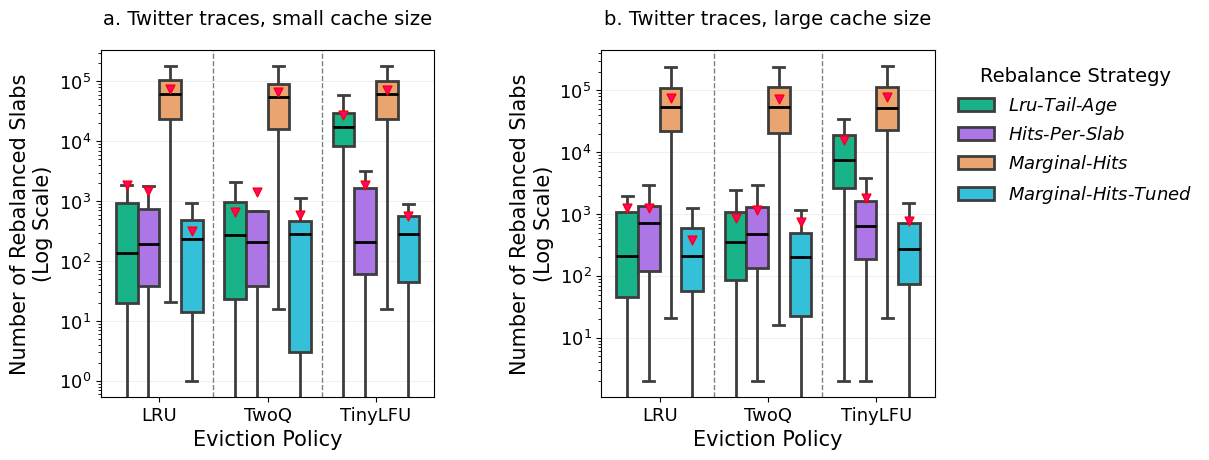

In [61]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.5}  # Increase wspace
)

# Plot the boxplots
plot_modern_boxplot_log_scale(df[~df['rebalance_strategy'].isin(['disabled', 'free-mem'])], 0.01, special_whisker=False, show_legend=False, ax=axes[0])
plot_modern_boxplot_log_scale(df[~df['rebalance_strategy'].isin(['disabled', 'free-mem'])], 0.1, special_whisker=False, show_legend=True, ax=axes[1])

# Add labels to the subplots
axes[0].set_title("a. Twitter traces, small cache size", fontsize=14, y=1.05)
axes[1].set_title("b. Twitter traces, large cache size", fontsize=14, y=1.05)

# Adjust layout for legend space
plt.subplots_adjust(right=0.82)  # Keep space for legend

# Save the figure to a PDF file with 300 DPI
plt.savefig("../../figures/twitter_rebalanced_slabs_boxplot_normal.pdf", dpi=300, bbox_inches="tight")

plt.show()

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1604480178.py:71: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_898847/1604480178.py:71: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



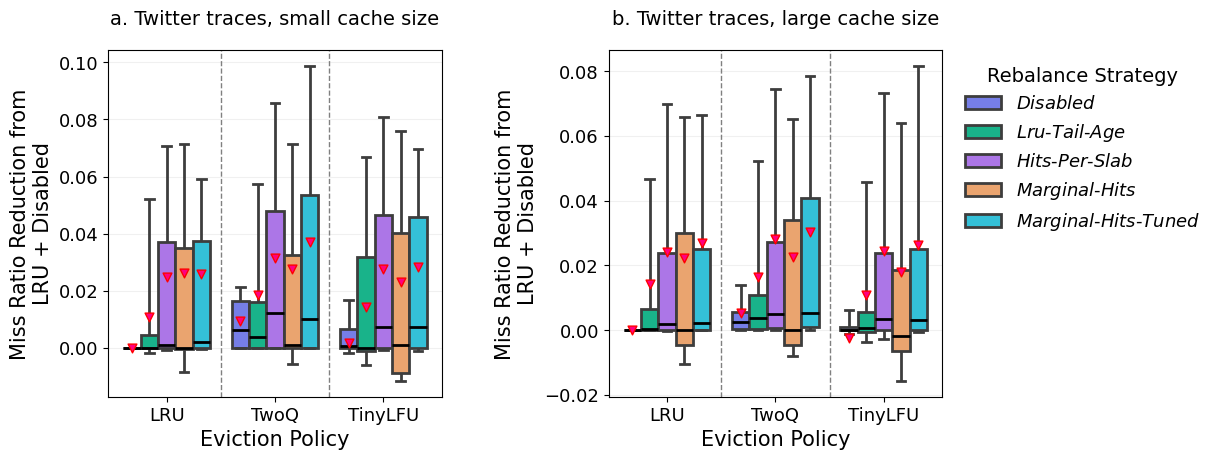

In [62]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.5}  # Increase wspace
)

# Plot the boxplots
plot_modern_boxplot(df[df['rebalance_strategy'] != 'free-mem'], 0.01, special_whisker=True, show_legend=False, ax=axes[0])
plot_modern_boxplot(df[df['rebalance_strategy'] != 'free-mem'], 0.1, special_whisker=True, show_legend=True, ax=axes[1])

# Add labels to the subplots
axes[0].set_title("a. Twitter traces, small cache size", fontsize=14, y=1.05)
axes[1].set_title("b. Twitter traces, large cache size", fontsize=14, y=1.05)

# Adjust layout for legend space
plt.subplots_adjust(right=0.82)  # Keep space for legend

# Save the figure to a PDF file with 300 DPI
plt.savefig("../../figures/twitter_miss_ratio_boxplot_special_whisker.pdf", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_2124060/425009701.py:75: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_2124060/425009701.py:75: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



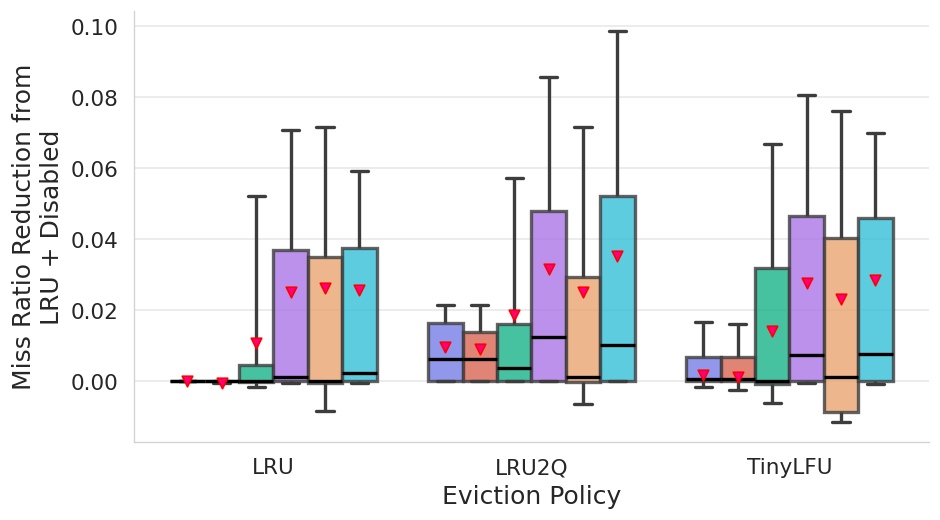

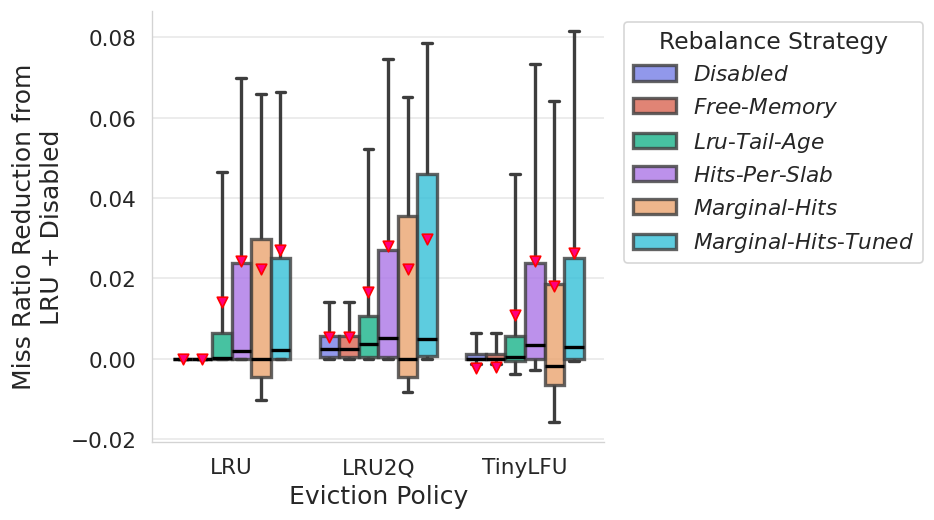

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.5}  # Increase wspace
)

plot_modern_boxplot(df, 0.01, special_whisker=True, show_legend=False, ax=axes[0])
plot_modern_boxplot(df, 0.1, special_whisker=True, show_legend=True, ax=axes[1])

plt.subplots_adjust(right=0.82)  # Keep space for legend
plt.show()

In [7]:
import plotly.express as px

def plot_boxplot_distribution(
    df,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title="Miss Ratio by Allocator and Rebalance Strategy"
):
    # Only keep selected strategies and set categorical order
    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]
    plot_df = df[df[color].isin(selected_strategies)].copy()
    plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    fig = px.box(
        plot_df,
        x=x,
        y=y,
        color=color,
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )
    fig.update_layout(
        boxmode='group',
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color
    )
    fig.show()

In [8]:
import plotly.express as px

def plot_barplot_distribution_by_trace(
    df,
    trace_name,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title=None
):
    # Filter by trace_name
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]
    plot_df = plot_df[plot_df[color].isin(selected_strategies)].copy()
    plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    if title is None:
        title = f"Miss Ratio by Allocator and Rebalance Strategy for {trace_name}"

    fig = px.bar(
        plot_df,
        x=x,
        y=y,
        color=color,
        barmode="group",
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color
    )
    fig.show()

In [9]:
plot_barplot_distribution_by_trace(df[(df['wsr'] == 0.01) & (df['allocator'] == 'LRU')], 'twitter_cluster11')

In [52]:
df[(df['wsr'] == 0.01) & (df['trace_name'] == 'twitter_cluster11') & (df['allocator'] == 'LRU') &
   (df['rebalance_strategy'].isin(['hits', 'marginal-hits', 'marginal-hits-tuned', 'disabled', 'tail-age']))]\
      [['rebalance_strategy', 'miss_ratio', 'n_rebalanced_slabs', 'uuid']]

,rebalance_strategy,miss_ratio,n_rebalanced_slabs,uuid
120,marginal-hits-tuned,0.428254,355,twitter_cluster11-50bedc57b7c85448c5bc0e80a409...
121,marginal-hits,0.434205,54624,twitter_cluster11-8eb591691d3a87dc66472f028d05...
122,disabled,0.453759,0,twitter_cluster11-89f912ba2c322ab5df2bace9e291...
123,hits,0.426685,21,twitter_cluster11-3121eaa3f8440cb83b1911f0bb66...
124,tail-age,0.466493,4,twitter_cluster11-3a7898eae2e7daf93140efc50a7e...
